# Imports

In [12]:
import sys
from pathlib import Path

current_dir = Path.cwd()
if current_dir.name == "notebooks":
    ROOT = current_dir.parent
else:
    ROOT = current_dir

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.black_scholes import BlackScholes
from src.portfolio import OptionsPortfolio
from src.stress_testing import StressTester
from src.utils import get_hist_prices

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# SPY + Parameters

In [13]:
ticker = "SPY"
prices = get_hist_prices(ticker, period="5y")
returns = np.log(prices / prices.shift(1)).dropna()

S = float(prices.iloc[-1])
sigma_hat = float(returns.std(ddof=1) * np.sqrt(252))
r = 0.03
q = 0.0

print(f"{ticker} S:", S)
print(f"Annualized vol:", sigma_hat)

SPY S: 750.3300170898438
Annualized vol: 0.17120033596587902


# Sample Portfolio

In [14]:
portfolio = OptionsPortfolio()

#position 1: long ATM call
opt1 = BlackScholes(S, S * 1.0, 0.25, r, sigma_hat, q=q)
portfolio.add_position(opt1, quantity=10.0, option_type="call", name="Long ATM Call")

#position 2: short OTM call
opt2 = BlackScholes(S, S * 1.05, 0.25, r, sigma_hat, q=q)
portfolio.add_position(opt2, quantity=-5.0, option_type="call", name="Short OTM Call")

#position 3: long OTM put
opt3 = BlackScholes(S, S * 0.95, 0.25, r, sigma_hat, q=q)
portfolio.add_position(opt3, quantity=8.0, option_type="put", name="Long OTM Put")

#position 4: short ATM put
opt4 = BlackScholes(S, S * 1.0, 0.25, r, sigma_hat, q=q)
portfolio.add_position(opt4, quantity=-3.0, option_type="put", name="Short ATM Put")

#position 5: long call spread
opt5a = BlackScholes(S, S * 0.98, 0.5, r, sigma_hat, q=q)
portfolio.add_position(opt5a, quantity=6.0, option_type="call", name="Call Spread Buy")

opt5b = BlackScholes(S, S * 1.08, 0.5, r, sigma_hat, q=q)
portfolio.add_position(opt5b, quantity=-6.0, option_type="call", name="Call Spread Sell")

#position 6: long put spread
opt6a = BlackScholes(S, S * 0.92, 0.5, r, sigma_hat, q=q)
portfolio.add_position(opt6a, quantity=5.0, option_type="put", name="Put Spread Buy")

opt6b = BlackScholes(S, S * 1.02, 0.5, r, sigma_hat, q=q)
portfolio.add_position(opt6b, quantity=-5.0, option_type="put", name="Put Spread Sell")

#position 7: long straddle
opt7a = BlackScholes(S, S * 1.0, 0.1, r, sigma_hat, q=q)
portfolio.add_position(opt7a, quantity=4.0, option_type="call", name="Straddle Call")

opt7b = BlackScholes(S, S * 1.0, 0.1, r, sigma_hat, q=q)
portfolio.add_position(opt7b, quantity=4.0, option_type="put", name="Straddle Put")

#position 8: short naked call
opt8 = BlackScholes(S, S * 1.1, 0.75, r, sigma_hat, q=q)
portfolio.add_position(opt8, quantity=-2.0, option_type="call", name="Short Naked Call")

# position 9: short straddle (creates negative vega to make stress test realistic)
opt9a = BlackScholes(S, S * 1.0, 0.25, r, sigma_hat, q=q)
portfolio.add_position(opt9a, quantity=-8.0, option_type="call", name="Short Straddle Call")

opt9b = BlackScholes(S, S * 1.0, 0.25, r, sigma_hat, q=q)
portfolio.add_position(opt9b, quantity=-8.0, option_type="put", name="Short Straddle Put")

print(f"Portfolio built with {len(portfolio.positions)} positions")

Portfolio built with 13 positions


# Net Greeks for Portfolio

In [15]:
net_delta = portfolio.net_delta()
net_gamma = portfolio.net_gamma()
net_vega = portfolio.net_vega()
net_theta = portfolio.net_theta()
net_rho = portfolio.net_rho()

print("\nPortfolio Net Greeks:")
print(f"  Net Delta:  {net_delta:.4f}")
print(f"  Net Gamma:  {net_gamma:.4f}")
print(f"  Net Vega:   {net_vega:.4f}")
print(f"  Net Theta:  {net_theta:.4f}")
print(f"  Net Rho:    {net_rho:.4f}")

print(f"  Net Delta of {net_delta:.4f} means: a $1 increase in SPY increases portfolio value by ~${net_delta:.2f}")


Portfolio Net Greeks:
  Net Delta:  5.4769
  Net Gamma:  0.0202
  Net Vega:   -1106.4168
  Net Theta:  -291.5069
  Net Rho:    1419.1585
  Net Delta of 5.4769 means: a $1 increase in SPY increases portfolio value by ~$5.48


# Dollar Greeks

In [16]:
dollar_greeks = portfolio.dollar_greeks(S)
print("\nDollar Greeks:")
print(f"  Dollar Delta (per 1% move):  ${dollar_greeks['dollar_delta']*0.01:.2f}")
print(f"  Dollar Gamma (convexity):    ${dollar_greeks['dollar_gamma']:.2f}")
print(f"  Dollar Vega (per 1 vol pt): ${dollar_greeks['dollar_vega_per_1pct']:.2f}")


Dollar Greeks:
  Dollar Delta (per 1% move):  $41.09
  Dollar Gamma (convexity):    $5685.17
  Dollar Vega (per 1 vol pt): $-11.06


# Position by Position Risk Report

In [17]:
risk_report = portfolio.risk_report()
print("\nPosition-by-Position Risk Report:")
print(risk_report.to_string(index=False))


Position-by-Position Risk Report:


               name  quantity option_type     delta     gamma         vega       theta         rho
      Long ATM Call      10.0        call  5.518816  0.061587  1484.017549 -623.830332  964.181049
     Short OTM Call      -5.0        call -1.650638 -0.028197  -679.432932  267.795479 -292.976558
       Long OTM Put       8.0         put -1.862450  0.038078   917.529200 -270.053433 -367.576509
      Short ATM Put      -3.0         put  1.344355 -0.018476  -445.205265  120.123976  269.288380
    Call Spread Buy       6.0        call  3.823962  0.024775  1193.978761 -281.476174 1284.443482
   Call Spread Sell      -6.0        call -1.955308 -0.023801 -1147.019541  237.112455 -679.038736
     Put Spread Buy       5.0         put -0.956362  0.014999   722.837674 -100.699475 -384.176291
    Put Spread Sell      -5.0         put  2.458401 -0.021956 -1058.090805  120.086630 1017.647857
      Straddle Call       4.0        call  2.131474  0.039150   377.350593 -368.912650  152.999698
       St

# Table

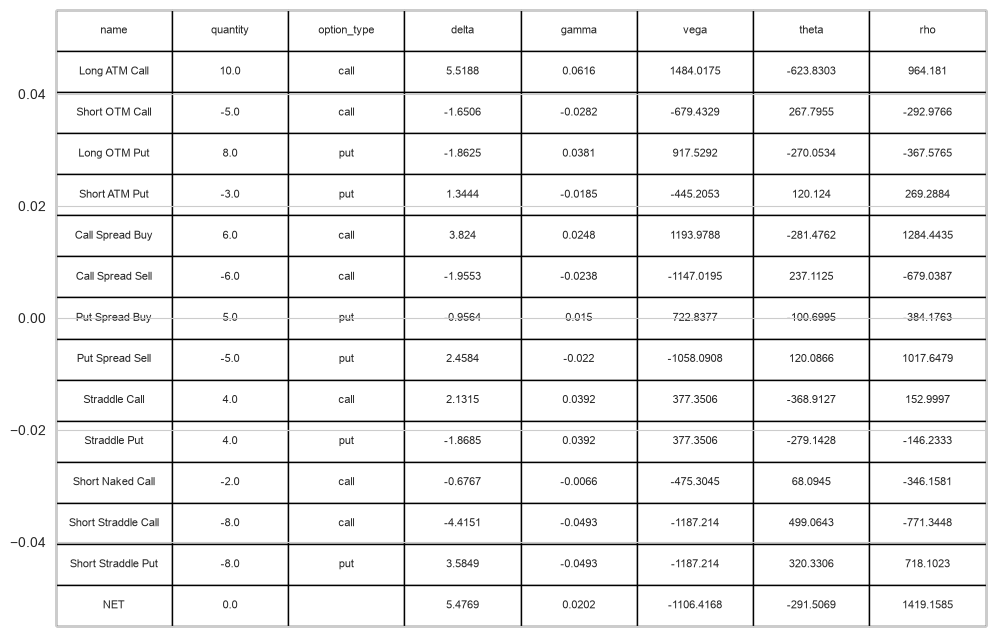

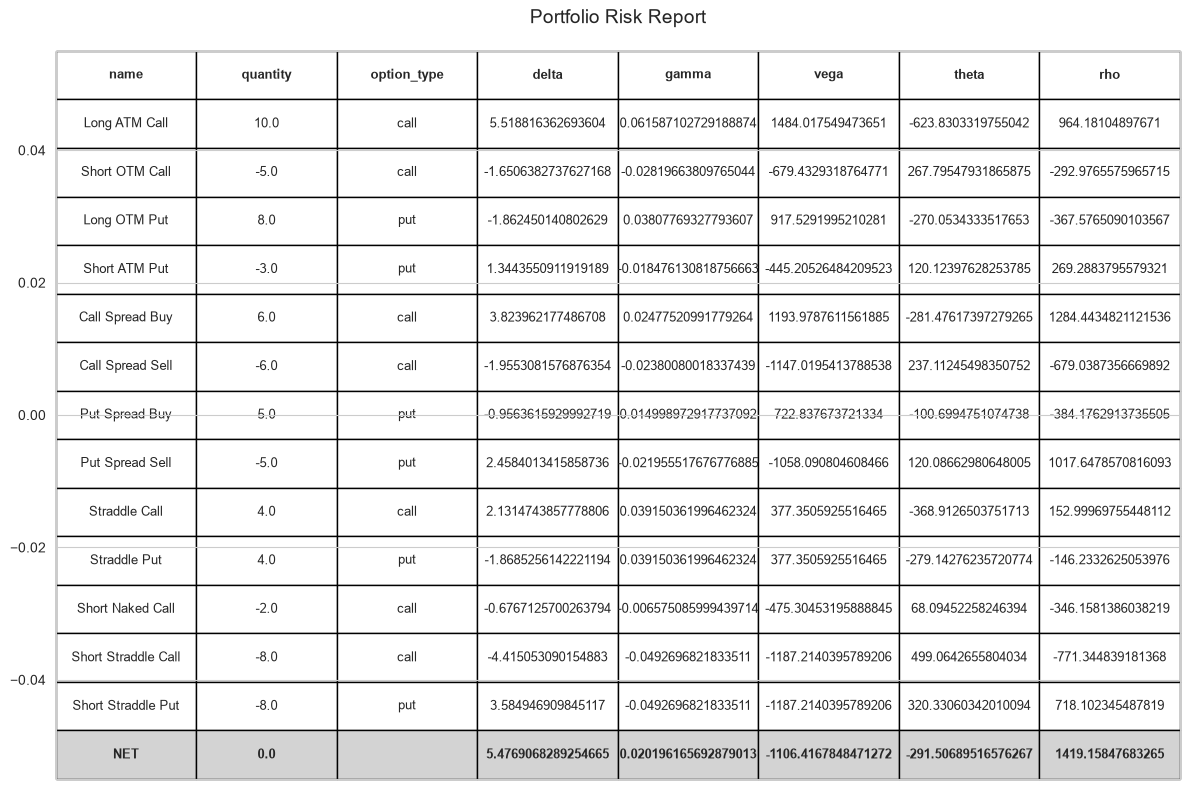

In [23]:
risk_report_display = risk_report.copy()
numeric_cols = ['delta', 'gamma', 'vega', 'theta', 'rho']
risk_report_display[numeric_cols] = risk_report_display[numeric_cols].round(4)

fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('tight')
ax.xaxis.set_visible(False)

table = ax.table(
    cellText=risk_report_display.values,
    colLabels=risk_report_display.columns,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)

table.auto_set_font_size(False)
table.set_fontsize(9)

for i in range(len(risk_report.columns)):
    table[(0, i)].set_text_props(weight='bold')

for i in range(len(risk_report)):
    if risk_report.iloc[i]['name'] == 'NET':
        for j in range(len(risk_report.columns)):
            table[(i+1, j)].set_facecolor('lightgray')
            table[(i+1, j)].set_text_props(weight='bold')

plt.title("Portfolio Risk Report", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Stress Test

In [19]:
tester = StressTester(portfolio, S, sigma_hat)
stress_results = tester.historical_scenarios()

print("\nHistorical Stress Test Results:")
print(stress_results.to_string(index=False))


Historical Stress Test Results:
    scenario  spot_move_pct  vol_move_pct  estimated_pnl
 COVID Crash          -0.30           2.0   -1100.018693
    2008 GFC          -0.20           1.5    -878.619046
 Volmageddon          -0.05           1.0    -380.680376
Dot-com Bust          -0.15           0.8    -640.041920
Soft Landing           0.20          -0.3    1106.130057


# Table 2

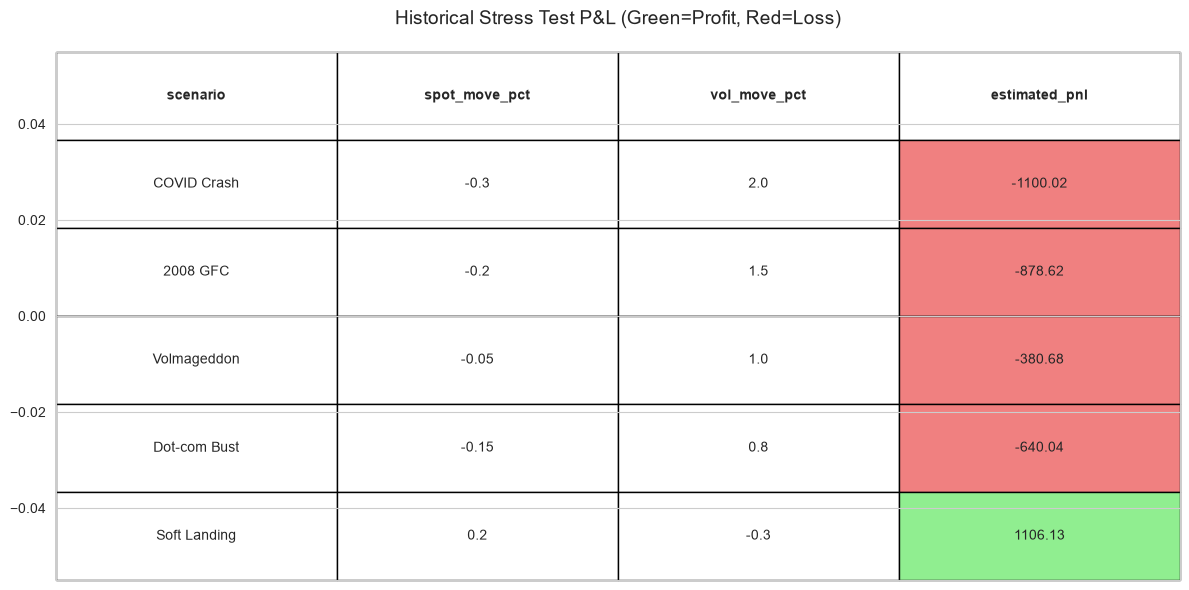

In [22]:
stress_results['estimated_pnl'] = stress_results['estimated_pnl'].round(2)

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('tight')
ax.xaxis.set_visible(False)

table = ax.table(
    cellText=stress_results.values,
    colLabels=stress_results.columns,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)

table.auto_set_font_size(False)
table.set_fontsize(10)

for i in range(len(stress_results.columns)):
    table[(0, i)].set_text_props(weight='bold')

for i in range(len(stress_results)):
    pnl = stress_results.iloc[i]['estimated_pnl']
    for j in range(len(stress_results.columns)):
        if stress_results.columns[j] == 'estimated_pnl':
            if pnl > 0:
                table[(i+1, j)].set_facecolor('lightgreen')
            elif pnl < 0:
                table[(i+1, j)].set_facecolor('lightcoral')

plt.title("Historical Stress Test P&L (Green=Profit, Red=Loss)", fontsize=14, pad=20)
plt.tight_layout()
stress_results['estimated_pnl'] = stress_results['estimated_pnl'].round(2)
plt.show()

# Heatmap

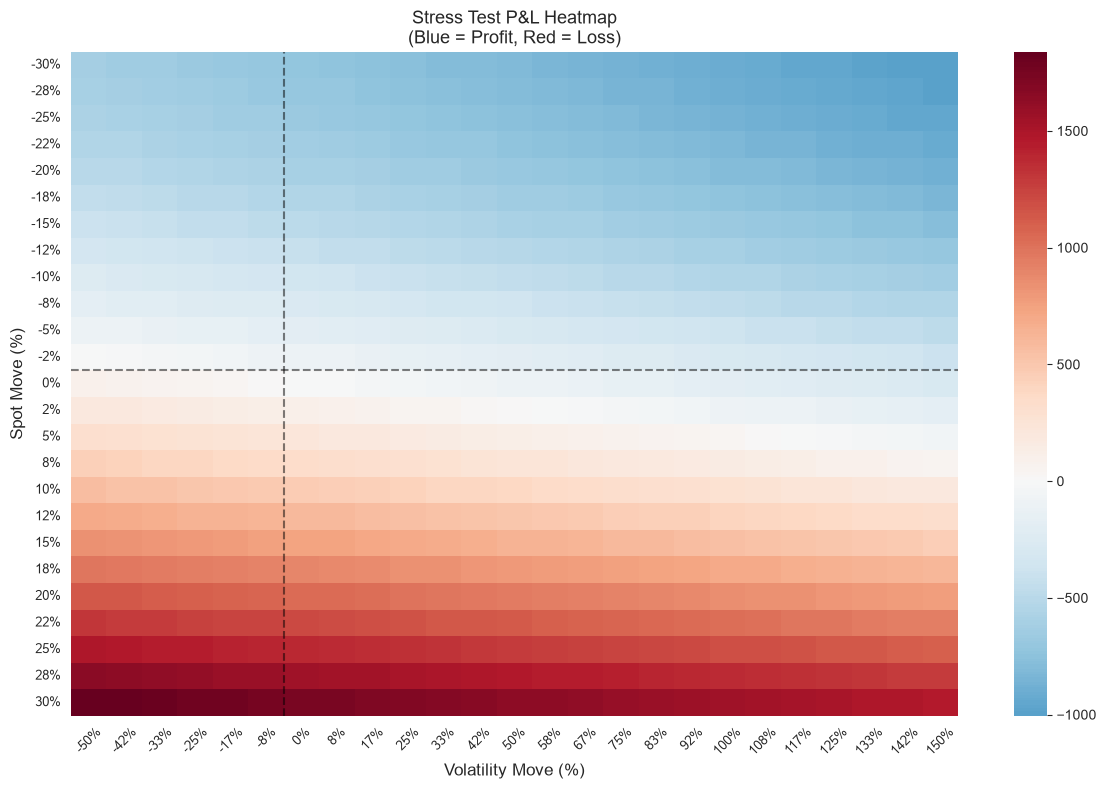

In [21]:
stress_surface = tester.stress_surface()

stress_surface['spot_move_pct'] = stress_surface['spot_move_pct'].round(3)
stress_surface['vol_move_pct'] = stress_surface['vol_move_pct'].round(3)

fig, ax = plt.subplots(figsize=(12, 8))
heatmap_data = stress_surface.pivot(
    index='spot_move_pct', 
    columns='vol_move_pct', 
    values='pnl'
)

x_labels = [f'{v:.0%}' for v in heatmap_data.columns]
y_labels = [f'{v:.0%}' for v in heatmap_data.index]

sns.heatmap(
    heatmap_data,
    cmap='RdBu_r',
    center=0,
    annot=False,      
    ax=ax,
    xticklabels=x_labels,
    yticklabels=y_labels
)

ax.set_xlabel('Volatility Move (%)', fontsize=12)
ax.set_ylabel('Spot Move (%)', fontsize=12)
ax.set_title('Stress Test P&L Heatmap\n(Blue = Profit, Red = Loss)', fontsize=13)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

zero_spot_idx = list(heatmap_data.index).index(min(heatmap_data.index, 
    key=lambda x: abs(x)))
ax.axhline(y=zero_spot_idx, color='black', linewidth=1.5, linestyle='--', alpha=0.5)

zero_vol_idx = list(heatmap_data.columns).index(min(heatmap_data.columns, 
    key=lambda x: abs(x)))
ax.axvline(x=zero_vol_idx, color='black', linewidth=1.5, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()